# Probability & Statistics (F) - Group 9

**Predicting Heart Disease - Kaggle Playground Series S6E2 Competition**

<br>

|    NRP     |      Name      |
| :--------: | :------------: |
| 5025241086 |  Callista Fidelya Roba Gultom |
| 5025241180 | Dilbina Windi Azahra |
| 5025241086 | Isabella Sienna Sulisthio |
| 5025241243 | Najma Lail Arazy |

Dataset: [Predicting Heart Disease](https://www.kaggle.com/competitions/playground-series-s6e2/data)

**Bayes’ Theorem**

Bayes’ Theorem is a mathematical formula used to determine the probability of an event based on prior knowledge of related conditions. It describes how the probability of a hypothesis changes when new evidence is observed.

P(A∣B)= P(B∣A)P(A) / P(B)​

P(A | B) → Posterior probability: the probability of event A occurring given that B is true.

P(B | A) → Likelihood: the probability of observing evidence B if A is true.

P(A) → Prior probability: the initial probability of event A before seeing evidence.

P(B) → Evidence probability: the probability of observing B.

Bayes’ Theorem is widely used in statistics, machine learning, medical diagnosis, and decision-making systems because it allows probabilities to be updated as new data becomes available.

**Application of Bayes’ Theorem in the Naive Bayes Algorithm**

The Naive Bayes algorithm is a classification method in machine learning that applies Bayes’ Theorem with the assumption that each feature is independent of the others given the class. This assumption simplifies the computation of probabilities when dealing with multiple features. In practice, the algorithm calculates the probability of each class given the observed features and then selects the class with the highest probability as the prediction. Because of its simplicity and efficiency, Naive Bayes is widely used in tasks such as text classification, spam detection, sentiment analysis, and medical data classification.

## Import Libraries

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings("ignore")


There are several libraries that we use for model development, as follows:
- **numpy & pandas** for numerical operations and data manipulation.
- **matplotlib.pyplot & seaborn** are used for statistical visualization and creating harts (such as line charts, bar charts, histograms, scatter plots, etc).
- **sklearn** is the main machine learning library, providing tools for prepocessing, model building, and evalution.
- **StratifiedKFold from sklearn.model_selection** used to split the dataset into K folds for cross-validation, it ensures each fold has the same proportion of class labels as the original dataset.
- **cross_val_score from sklearn.model_selection** takes a model and dataset, run it through all K folds, and returns a score for each fold.
- **StandardScaler from sklearn.preprocessing** rescales numeric features so they all have mean = 0 and standard deviation = 1.
- **PowerTransformer from sklearn.preprocessing** transforms skewed data to be more Gaussian.
- **ColumnTransformer from sklearn.compose** applies different transformatins to different columns simultaneously
- **Pipeline from sklearn.pipeline** chain
- **GaussianNB, BernoulliNB from sklearn.naive_bayes**
- **OneHotEncoder from sklearn.preprocessing**

## Load Data

After importing all the required libraries for data processing, visualization, and modeling, the next step is to load the dataset from the **"Kaggle Playground Series S6E2 Competition - Predicting Heart Disease"**. After loading the dataset, we can examine the shape of the training and testing data, as well as display the first five rows of the training data.

In [ ]:

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

train.head()


(630000, 15)
(270000, 14)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## EDA

After loading the dataset, the next step is Exploratory Data Analysis (EDA). This stage performed to understand the structure and characteristics of the data before proceeding to preprocessing and modeling. In this proess, the dataset information is checked using `.info()` to identify data types and non-null values, while `.describe()` is used to obtain descriptive statistics such as mean, standar deviation, minimum, maximum values, etc. We also checked for missing values by using `.isnull().sum()` to ensure data completeness.

Beside that, several visualizations are created to better understand the distribution of numerical features such as Age, BP, Cholesterol, Max HR, and ST Depression. Histogram are used to observe feature distributions, while countplots and boxplots help analyze the relationship between individual features and the target variable (Heart Disease).

A correlation heatmap is also generated to identify relationships between num features and the target variable. The feature correlations with the target variable are examined to identify potentially important predictors for the modeling stage.

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  int64  
 14  hr_a

In [ ]:
train.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,hr_age_ratio,chol_bp_ratio,st_severity
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873,0.448340,2.844703,1.886842,0.314954
std,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007,0.497324,0.610451,0.334881,0.758100
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.910256,0.741294,0.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,2.419355,1.649007,0.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.000000,2.774194,1.867769,0.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000,3.217391,2.099174,0.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,6.733333,5.081081,6.200000


In [ ]:
train.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


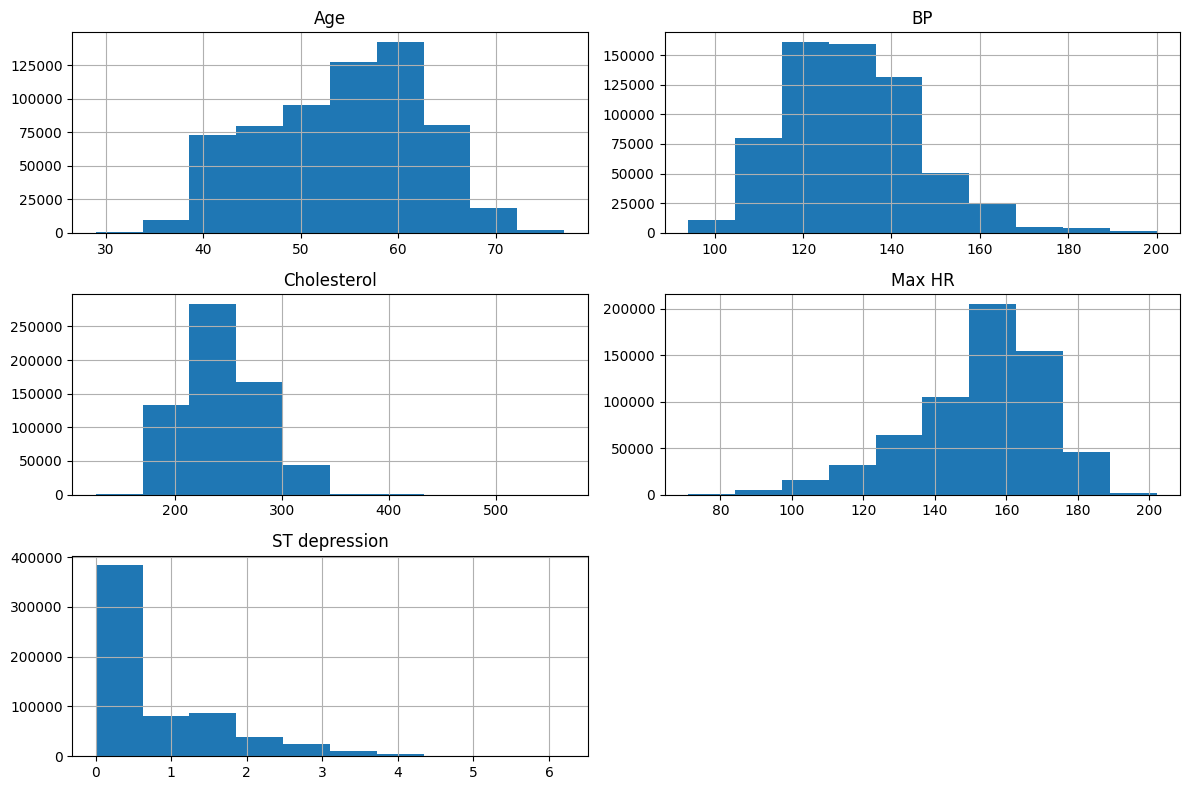

In [ ]:
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

train[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

,proportion
Heart Disease,
Absence,0.55166
Presence,0.44834


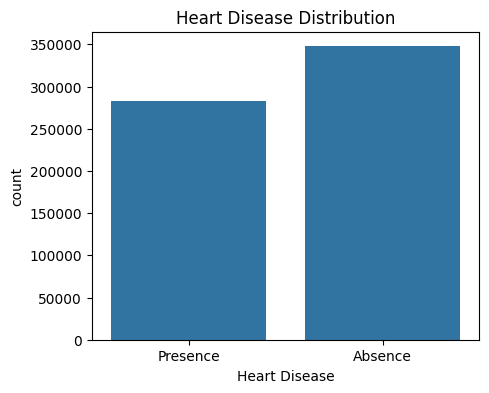

In [ ]:
display(train['Heart Disease'].value_counts(normalize=True))
plt.figure(figsize=(5,4))
sns.countplot(data=train, x='Heart Disease')
plt.title("Heart Disease Distribution")
plt.show()

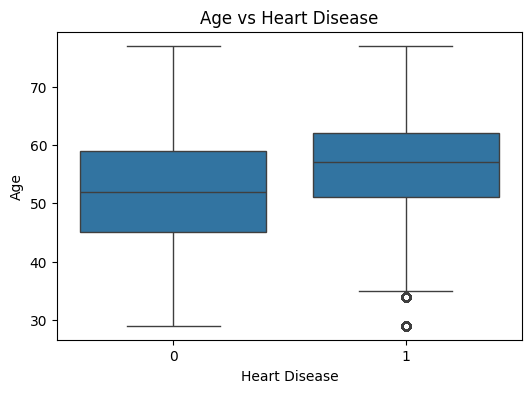

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train, x='Heart Disease', y='Age')
plt.title('Age vs Heart Disease')
plt.show()

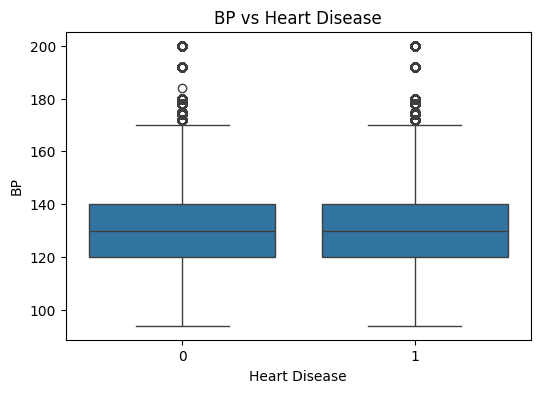

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train, x='Heart Disease', y='BP')
plt.title('BP vs Heart Disease')
plt.show()

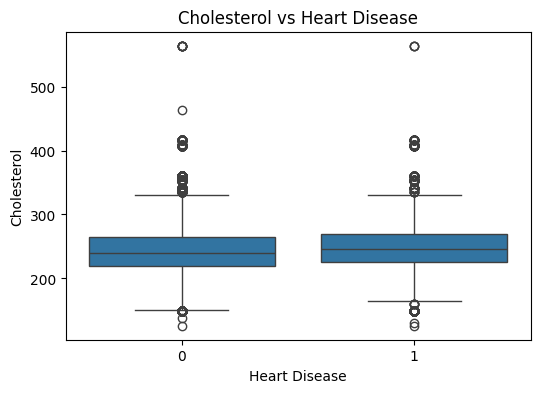

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train, x='Heart Disease', y='Cholesterol')
plt.title('Cholesterol vs Heart Disease')
plt.show()

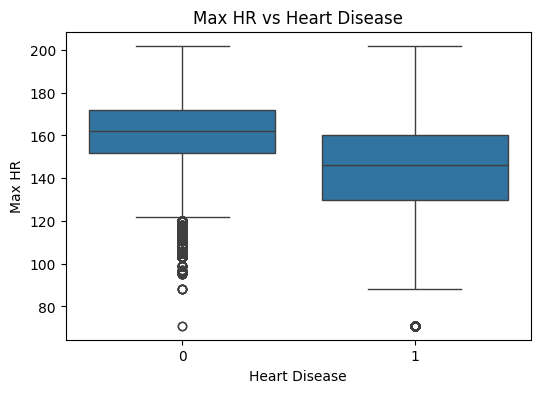

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train, x='Heart Disease', y='Max HR')
plt.title('Max HR vs Heart Disease')
plt.show()

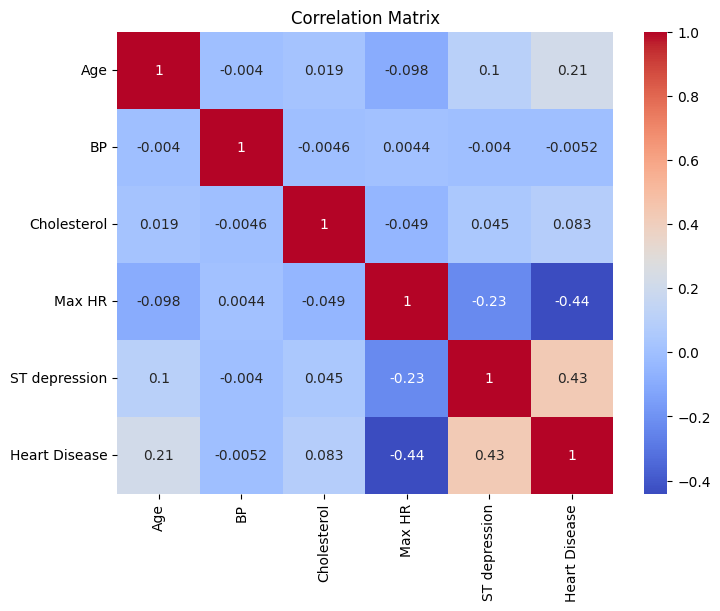

In [ ]:
plt.figure(figsize=(8,6))

selected = num_cols + ['Heart Disease']

sns.heatmap(train[selected].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

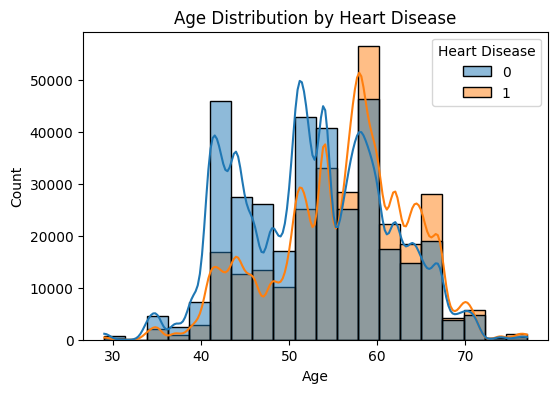

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=train, x='Age', hue='Heart Disease', bins=20, kde=True)
plt.title("Age Distribution by Heart Disease")
plt.show()

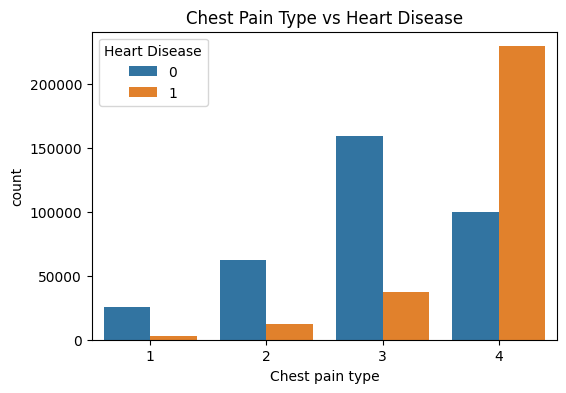

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Chest pain type', hue='Heart Disease')
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [ ]:
corr = train.corr()['Heart Disease'].sort_values(ascending=False)
print(corr)

Heart Disease              1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
st_severity                0.394162
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
chol_bp_ratio              0.066213
FBS over 120               0.033570
BP                        -0.005181
hr_age_ratio              -0.411846
Max HR                    -0.440985
Name: Heart Disease, dtype: float64


## Target Encoding

The target variable `Heart Disease` is converted from categorical labels into numerical values so that it can be processed by machine learning algorithms. In this mapping, Absence is encoded as 0, while Presence is encoded as 1.

In [ ]:

train["Heart Disease"] = train["Heart Disease"].map({
    "Absence":0,
    "Presence":1
})


## Save Test IDs

We need to save the `id` column from the test dataset separately because it will be needed later when generating the final prediction submission file.

In [ ]:
test_ids = test["id"]

## Drop ID

After that, the `id` column is removed from both training and testing datasets since it does not provide meaningful information for model training

In [ ]:
train = train.drop(columns=["id"])
test = test.drop(columns=["id"])

## Feature Engineering

Furthermore, feature engineering is performed to create additional features that may improve model performane by capturing relationships between existing variables. In this step, three new features are generated based on domain-related combinations of the originall features.

* `hr_age_ratio` represents the ratio between maximum heart rate and age, which may reflect cardiovascular performance relative to age.
* `chol_bp_ratio` represents the ratio between cholesterol level and blood presure, potentially indicating metabolic and circulatory conditions.
* `st_severity` represents severity of stress-related heart abnormalities by combines ST depression with exercise-induced angina.

In [ ]:

def feature_engineering(df):

    df["hr_age_ratio"] = df["Max HR"] / (df["Age"] + 1)
    df["chol_bp_ratio"] = df["Cholesterol"] / (df["BP"] + 1)
    df["st_severity"] = df["ST depression"] * df["Exercise angina"]

    return df

train = feature_engineering(train)
test = feature_engineering(test)


### Feature Types

The features are grouped into numerical and categorical variables based on their characteristics. This separation is important because different preprocessing methods will be applied to each feature type during the modeling pipeline. Numerical features are processed using the numeric transformer, which applies power transformation and standard scaling, while categorical features are handled by the categorical transformer using one-hot encoding before being used by the machine learning models.

In [ ]:

numeric_features = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression",
    "hr_age_ratio",
    "chol_bp_ratio",
    "st_severity"
]

categorical_features = [
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium"
]


## Split Features and Target

After defining the feature types, the dataset is split into input features (`X`) and target variable (`y`). The target column `Heart Disease` is separated from the training data so that the model can learn patterns from the input features and predict the target label.

In [ ]:

X = train.drop("Heart Disease", axis=1)
y = train["Heart Disease"]


## Preprocessing Pipeline

A preprocessing pipeline is created to ensure that numerical and categorical features are processed appropriately before being passed to the machine learning model. Different transformations are applied depending on the feature type.

For numerical features, two transformations are applied sequentially. First, `PowerTransformer` with the Yeo-Johnson method is used to reduce skewness and make feature distributions closer to normal. After that, `StandardScaler` standardizes the features by centering them around zero with unit variance.

Meanwhile, the categorical features are encoded using `OneHotEncoder` which converts categorical values into binary columns so they can be processed by ML Algorithms. The `handle_unknown="ignore"` option ensures that unseen categories in the test data don't cause errors during prediction.

In [ ]:

numeric_transformer = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Since the task requires the use of Naive Bayes algorithms, Gaussian Naive Bayes and Bernoulli Naive Bayes are selected because both represent different variants of Naive Bayes that handle feature distributions differently. This allows a comparison of how each variant performs on the heart disease dataset.

Gaussian Naive Bayes is chosen because the dataset contains several numerical features such as Age, BP, Cholesterol, and Max HR, which are continuous variables and can be modeled using Gaussian distribution assumptions.

Bernoulli Naive Bayes is selected as a comparison because categorical features are transformed into binary values through one-hot encoding, making Bernoulli Naive Bayes relevant for binary feature representations.

Using both models helps evaluate which Naive Bayes variant is more suitable for the dataset after preprocessing and feature transformation.

## Gaussian Naive Bayes Pipeline

In [ ]:

gnb_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", GaussianNB())
])


## Bernoulli Naive Bayes Pipeline

In [ ]:

bnb_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", BernoulliNB())
])


## Cross Validation

Cross validation is performed to evaluate model performance more reliably before selecting the final model. In this step, `StratifiedKFold` is used to split the dataset into five folds while preserving the proportion of target classes in each fold. This is important because the target variable contains two classes and balanced distribution should be maintained during validation.

In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gnb_score = cross_val_score(
    gnb_pipeline,
    X,
    y,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

print("GaussianNB CV AUC:", gnb_score.mean())


GaussianNB CV AUC: 0.9230191224196573


The Gaussian Naive Bayes pipeline is evaluated using cross-validation with `roc_auc` as the scoring metric. ROC-AUC is selected because it is the official evaluation metric used in the Kaggle competition, making it the most appropriate metric for validating model performance during training. Since the target variable is binary (0 for Absence and 1 for Presence), ROC-AUC is suitable because it measures how well the model distinguishes between the two classes across different classification thresholds.

In [ ]:

bnb_score = cross_val_score(
    bnb_pipeline,
    X,
    y,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

print("BernoulliNB CV AUC:", bnb_score.mean())


BernoulliNB CV AUC: 0.9452166092848714


The Bernoulli Naive Bayes pipeline is also evaluated using cross-validation with roc_auc as the scoring metric to ensure a fair comparison under the same evaluation standard.

## Select Best Model

In [ ]:

if gnb_score.mean() > bnb_score.mean():
    model = gnb_pipeline
    print("Using GaussianNB")
else:
    model = bnb_pipeline
    print("Using BernoulliNB")


Using BernoulliNB


Based on the ROC-AUC scores of both models, the model with the higher AUC score is selected as the final model for training and prediction. In this case, Bernoulli Naive Bayes is chosen as the final model because it produces a higher ROC-AUC score, reaching 0.945.

## Train Final Model

The selected model is then trained using the full training dataset so that all available data contributes to learning before making predictions on the test set.

In [ ]:

model.fit(X, y)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('power',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BP', 'Cholesterol',
                                                   'Max HR', 'ST depression',
                                                   'hr_age_ratio',
                                                   'chol_bp_ratio',
                                                   'st_severity']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Chest pain type',
                                                   'FBS over 120',
                                                   'EKG results',
                                                   'Exercise angina',
                                                   'Slope of ST',
                                                   'Number of vessels fluro',
                                                   'Thallium'])])),
                ('model', BernoulliNB())])

## Predict Test Set

Predictions are generated on the test dataset using probability outputs. The probability of class 1 (Presence of Heart Disease) is extracted because the competition requires probability-based predictions rather than class labels.

In [ ]:

test_pred = model.predict_proba(test)[:,1]


After the model successfully makes predictions on the test dataset, the final step is to create and save the submission file (submission.csv) for submission to the Kaggle competition.

## Create Submission

In [ ]:

submission = pd.DataFrame({
    "id": test_ids,
    "Heart Disease": test_pred
})

submission.head()


,id,Heart Disease
0,630000,9.999837e-01
1,630001,3.791617e-07
2,630002,9.999990e-01
3,630003,7.269740e-07
4,630004,2.584003e-01


## Save Submission

In [ ]:
submission.to_csv("submission.csv", index=False)